In [120]:
import numpy as np
import csv
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import preprocessing
from tensorflow.keras.layers import Normalization, Resizing
from tensorflow.keras import layers
from tensorflow.keras import models
from sklearn.utils.class_weight import compute_class_weight

import pandas as pd

import seaborn as sns

from scipy import signal
from scipy.signal import butter, filtfilt, iirnotch, periodogram

In [121]:

cratch_np = np.load('scratch.npy', allow_pickle=True)
rest_np = np.load('rest.npy', allow_pickle=True)
other_np = np.load('other.npy', allow_pickle=True)

vishal_scratch = (np.load('vishal_scratch_1.npy', allow_pickle=True))
vishal_rest = (np.load('vishal_rest_1.npy', allow_pickle=True))
vishal_other = (np.load('vishal_other_1.npy', allow_pickle=True))
sid_scratch = (np.load('sid_scratch_1.npy', allow_pickle=True))
sid_rest = (np.load('sid_rest_1.npy', allow_pickle=True))
sid_other = (np.load('sid_fist_1.npy', allow_pickle=True))
ariel_scratch = (np.load('ariel_scratch_1.npy', allow_pickle=True))
ariel_rest = (np.load('ariel_rest_1.npy', allow_pickle=True)) 
ariel_other = (np.load('ariel_other_1.npy', allow_pickle=True))
raina_scratch = (np.load('raina_scratch_1.npy', allow_pickle=True))
raina_rest = (np.load('raina_rest_1.npy', allow_pickle=True))
raina_other = (np.load('raina_other_1.npy', allow_pickle=True))
aryan_scratch = (np.load('aryan_scratch_1.npy', allow_pickle=True))
aryan_rest = (np.load('aryan_rest_1.npy', allow_pickle=True))
# print(aryan_rest.shape)
aryan_other = (np.load('aryan_other_1.npy', allow_pickle=True))

print(vishal_other.shape, sid_other.shape, ariel_other.shape, raina_other.shape, aryan_other.shape)

(120000,) (120000,) (120000,) (120000,) (120000,)


In [141]:
def normalize(data):
    data = data - np.mean(data)
    data = (data - data.min()) / (data.max() - data.min())
    return data

def bandpass_filter(data, lowcut=40.0, highcut=200.0, fs=1000.0, order=4):
    nyq = 0.5 * fs
    b, a = butter(order, [lowcut/nyq, highcut/nyq], btype='band')
    return filtfilt(b, a, data)

def find_noise_frequency(data, fs=1000.0):
    f, Pxx = periodogram(data, fs=fs)
    idx = np.argmax(Pxx)
    return f[idx]

def adaptive_notch_filter(data, fs=1000.0, quality=30):
    freq = find_noise_frequency(data, fs=fs)
    nyq = 0.5 * fs
    b, a = iirnotch(freq/nyq, quality)
    return filtfilt(b, a, data)

def cleanup(data):
    data = normalize(data)
    data = bandpass_filter(data)
    # data = adaptive_notch_filter(data)
    return data

def stft(x, sampling_rate=1000):
    f, t, spec = signal.stft(x.numpy(), fs=sampling_rate, nperseg=255, noverlap = 50, nfft=256, boundary='zeros')
    return tf.convert_to_tensor(np.abs(spec))

def stft_full(x, sampling_rate=1000, useNp=False): # for visualization
    if not useNp:
        X = x.numpy()
    else:
        X = x
    f, t, spec = signal.stft(X, fs=sampling_rate, nperseg=255, noverlap = 50, nfft=256, boundary='zeros')
    return f, t, tf.convert_to_tensor(np.abs(spec))

def get_spectrogram(data: np.ndarray):
    # f, t, z = signal.stft(data, fs=200, nperseg=128, noverlap=50, nfft=128)
    spectrogram = tf.py_function(func=stft, inp=[data], Tout=tf.float32)
    spectrogram = tf.image.resize(spectrogram[..., tf.newaxis], [129, 124])
    spectrogram = tf.squeeze(spectrogram, -1)
    # spectrogram.set_shape((129, 124))
    return spectrogram

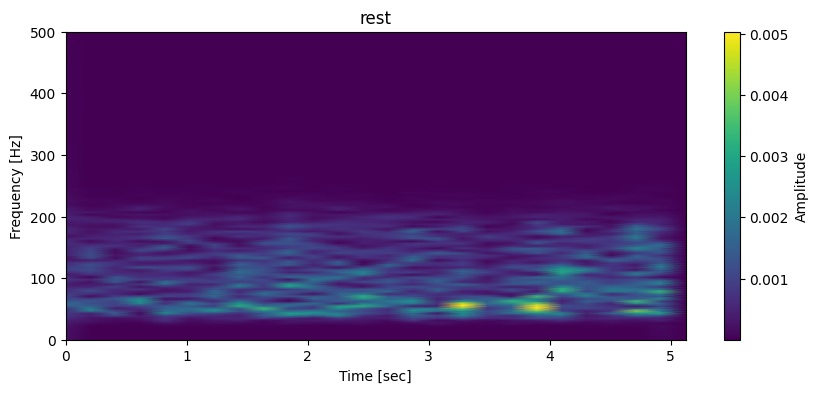

In [142]:


vishal_other_c = cleanup(vishal_other)[-5000:]

f, t, spec = stft_full(vishal_other_c, useNp=True)

plt.figure(figsize=(10, 4))
plt.pcolormesh(t, f, spec, shading='gouraud')
plt.title('rest')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.colorbar(label='Amplitude')  # limit frequency range to make plot clearer
# plt.savefig('scratch_data_800Hz.png')
plt.show()



(129, 11)


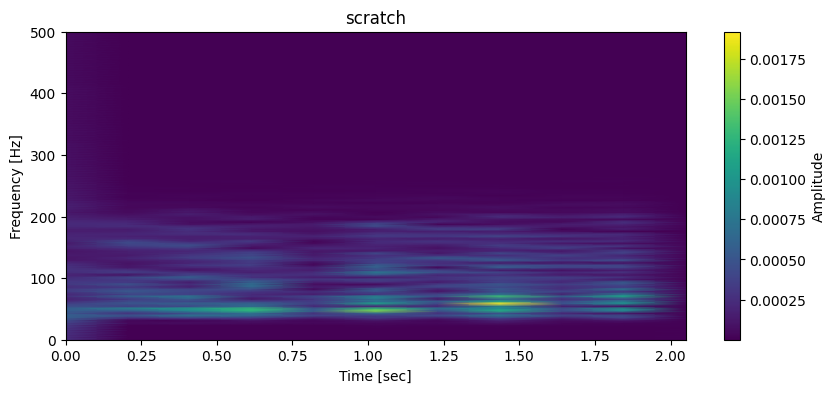

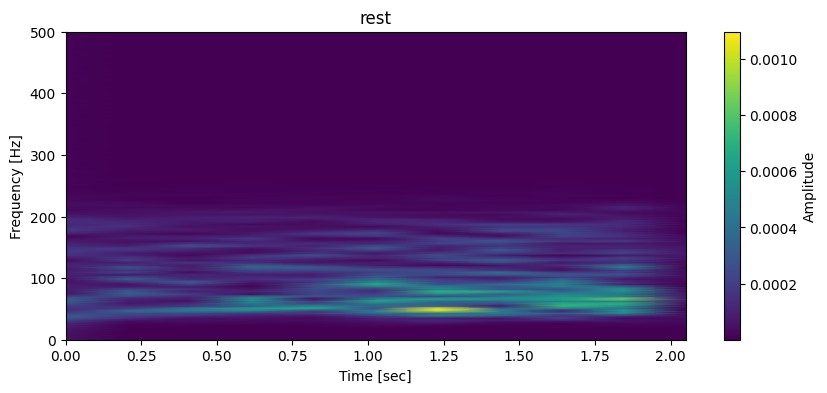

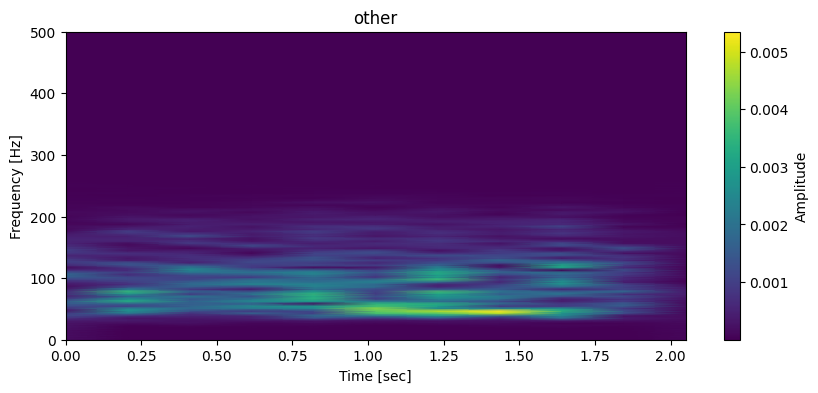

In [143]:
"""

vishal_scratch = cleanup(vishal_scratch)
vishal_rest = cleanup(vishal_rest)
vishal_other = cleanup(vishal_other)

"""

aryan_scratch_c = cleanup(aryan_scratch)[-2000:]
aryan_rest_c = cleanup(aryan_rest)[-2000:]
aryan_other_c = cleanup(aryan_other)[-2000:]

f1, t1, spec_scratch = stft_full(aryan_scratch_c, sampling_rate=1000, useNp=True)
f2, t2, spec_rest = stft_full(aryan_rest_c, sampling_rate=1000, useNp=True)
f3, t3, spec_other = stft_full(aryan_other_c, sampling_rate=1000, useNp=True)

print(spec_scratch.shape)

plt.figure(figsize=(10, 4))
plt.pcolormesh(t1, f1, spec_scratch, shading='gouraud')
plt.title('scratch')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.colorbar(label='Amplitude')  # limit frequency range to make plot clearer
# plt.savefig('scratch_data_800Hz.png')
plt.show()

plt.figure(figsize=(10, 4))
plt.pcolormesh(t2, f2, spec_rest, shading='gouraud')
plt.title('rest')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.colorbar(label='Amplitude')  # limit frequency range to make plot clearer
# plt.savefig('scratch_data_800Hz.png')
plt.show()

plt.figure(figsize=(10, 4))
plt.pcolormesh(t3, f3, spec_other, shading='gouraud')
plt.title('other')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.colorbar(label='Amplitude')  # limit frequency range to make plot clearer
# plt.savefig('scratch_data_800Hz.png')
plt.show()

In [144]:
# helper functions to train the model

def get_sample(data, start, sampling_rate=1000):
    end = start + sampling_rate
    return data[start:end]

def get_data(filepath):
    df = pd.read_csv(filepath)
    return df[['v1', 'v2', 'label']].to_numpy()

def clean_data(data: np.ndarray):
    v1 = data[:, 0]
    labels = data[:, 1]

    v1_cleaned = cleanup(v1)

    return np.column_stack((v1_cleaned, labels))

def get_spectrograms(data: np.ndarray, sampling_rate=1000, verbose=False):

    v1 = data[:, 0]
    labels = data[:, 1]

    num_samples = data.shape[0]

    all_spec = []
    all_labels = []

    for i in range(0, num_samples - 2000 + 1, 100):
        
        sample1 = get_sample(v1, i, sampling_rate=2000)
        # print(len(sample1)
        # print(sample1.shape, sample2.shape)
        sample1 = tf.convert_to_tensor(sample1, dtype=tf.float32)
        
        spec1 = get_spectrogram(sample1)
        
        if verbose:
            print(f"Processing sample {i} to {i + int(sampling_rate)}")
            print(sample1.shape)
    

        all_spec.append(spec1)
        all_labels.append(tf.cast(labels[i], tf.int32))

    # print(all_spec, all_labels)

    return tf.stack(all_spec, axis=0), tf.stack(all_labels, axis=0)

def split_data(data: np.ndarray, split_ratio=0.8):
    num_samples = data.shape[0]
    split_index = int(num_samples * split_ratio)
    
    train_data = data[:split_index]
    test_data = data[split_index:]
    
    return train_data, test_data


In [145]:
labels = {'scratch': 0, 'rest': 1, 'other': 2}

scratch_complete = np.concatenate((vishal_scratch, sid_scratch, ariel_scratch, raina_scratch, aryan_scratch), axis=0)
rest_complete = np.concatenate((vishal_rest, sid_rest, ariel_rest, raina_rest, aryan_rest), axis=0)
other_complete = np.concatenate((vishal_other, sid_other, ariel_other, raina_other, aryan_other), axis=0)

print(scratch_complete.shape, rest_complete.shape, other_complete.shape)

scratch_label = np.array([labels['scratch']] * scratch_complete.shape[0])
rest_label = np.array([labels['rest']] * rest_complete.shape[0])
other_label = np.array([labels['other']] * other_complete.shape[0])

scratch_complete = np.stack([scratch_complete, scratch_label], axis=1)
rest_complete = np.stack([rest_complete, rest_label], axis=1)
other_complete = np.stack([other_complete, other_label], axis=1)

print(scratch_complete.shape, rest_complete.shape, other_complete.shape)

(600000,) (600000,) (600000,)
(600000, 2) (600000, 2) (600000, 2)


In [146]:
scratch_data = clean_data(scratch_complete)
rest_data = clean_data(rest_complete)   
other_data = clean_data(other_complete)

df_scratch_train, df_scratch_test = split_data(scratch_data)
df_rest_train, df_rest_test = split_data(rest_data)
df_other_train, df_other_test = split_data(other_data)

spec_scratch_train, scratch_labels = get_spectrograms(df_scratch_train, sampling_rate=1000)
spec_rest_train, rest_labels = get_spectrograms(df_rest_train, sampling_rate=1000)
spec_other_train, other_labels = get_spectrograms(df_other_train, sampling_rate=1000)

spec_scratch_test, scratch_labels_test = get_spectrograms(df_scratch_test, sampling_rate=1000)
spec_rest_test, rest_labels_test = get_spectrograms(df_rest_test, sampling_rate=1000)
spec_other_test, other_labels_test = get_spectrograms(df_other_test, sampling_rate=1000)

spec_scratch_test.shape


TensorShape([1181, 129, 124])

In [147]:
ds_scratch_train = tf.data.Dataset.from_tensor_slices((spec_scratch_train, scratch_labels))
ds_rest_train = tf.data.Dataset.from_tensor_slices((spec_rest_train, rest_labels))
ds_other_train = tf.data.Dataset.from_tensor_slices((spec_other_train, other_labels))

ds_scratch_test = tf.data.Dataset.from_tensor_slices((spec_scratch_test, scratch_labels_test))
ds_rest_test = tf.data.Dataset.from_tensor_slices((spec_rest_test, rest_labels_test))
ds_other_test = tf.data.Dataset.from_tensor_slices((spec_other_test, other_labels_test))


complete_training_set = ds_scratch_train.concatenate(ds_rest_train).concatenate(ds_other_train)
complete_test_set = ds_scratch_test.concatenate(ds_rest_test).concatenate(ds_other_test)

spec_all_test = tf.concat([spec_scratch_test, spec_rest_test, spec_other_test], axis=0)
label_all_test = tf.concat([scratch_labels_test, rest_labels_test, other_labels_test], axis=0)
# print(type(spec_all_test), spec_all_test.shape)

spec_all_test = tf.expand_dims(spec_all_test, axis=-1)


spec_all_train = tf.concat([spec_scratch_train, spec_rest_train, spec_other_train], axis=0)
spec_all_train = tf.expand_dims(spec_all_train, axis=-1)
label_all_train = tf.concat([scratch_labels, rest_labels, other_labels], axis=0)


In [148]:
for spectrogram, label in complete_training_set.take(1):
    print("Spectrogram shape:", spectrogram.shape)
    print("Label:", label.numpy())

# classes = np.unique(labels)  # [0, 1, 2] -> rest, scratch, other
# weights = compute_class_weight(class_weight='balanced', classes=classes, y=label_all_train.numpy())
# class_weights = dict(zip(classes, weights))

# class_weights[1] *= 1.5

# print("Class weights:", class_weights)

Spectrogram shape: (129, 124)
Label: 0


In [149]:
for spectrogram, label in complete_training_set.take(1):
    input_shape = spectrogram.shape
    print("Spectrogram shape:", spectrogram.shape)
    print("Label:", label.numpy())

batch_size = 64

size = tf.data.experimental.cardinality(complete_training_set).numpy()
print("Dataset size:", size)

train_ds = tf.data.Dataset.from_tensor_slices((spec_all_train, label_all_train))
train_ds = train_ds.shuffle(buffer_size=len(label_all_train), reshuffle_each_iteration=True)
train_ds = train_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((spec_all_test, label_all_test))
val_ds = val_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

norm_layer = Normalization()
norm_layer.adapt(train_ds.map(lambda x, _: x))

for x, y in train_ds.take(1):
    print(x.shape)

model = tf.keras.Sequential([
    layers.Input(shape=(129, 11, 1)),
    layers.Resizing(32, 32),
    norm_layer,
    layers.Conv2D(32, 3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, 3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.3),
    layers.Conv2D(128, 3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.4),
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(3, activation='softmax')
])
model.summary()

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])


Spectrogram shape: (129, 124)
Label: 0
Dataset size: 14343
(64, 129, 124, 1)


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing_11 (Resizing)          │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalization_11                │ (None, 32, 32, 1)      │             3 │
│ (Normalization)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_33          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_34          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_33 (Dropout)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_35          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_34 (Dropout)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_11     │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_35 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,470 (431.53 KB)

 Trainable params: 110,019 (429.76 KB)

 Non-trainable params: 451 (1.77 KB)

In [150]:
epochs = 30
history = model.fit(
    train_ds, 
    validation_data=val_ds,  
    epochs=epochs,
    callbacks=tf.keras.callbacks.EarlyStopping(verbose=1, patience=5),
)

Epoch 1/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 71s 303ms/step - accuracy: 0.6481 - loss: 0.6874 - val_accuracy: 0.5095 - val_loss: 2.3123
Epoch 2/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 69s 304ms/step - accuracy: 0.7375 - loss: 0.4970 - val_accuracy: 0.5509 - val_loss: 1.7809
Epoch 3/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 70s 307ms/step - accuracy: 0.7490 - loss: 0.4709 - val_accuracy: 0.3751 - val_loss: 1.6649
Epoch 4/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 70s 308ms/step - accuracy: 0.7603 - loss: 0.4442 - val_accuracy: 0.6097 - val_loss: 1.7454
Epoch 5/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 69s 305ms/step - accuracy: 0.7674 - loss: 0.4369 - val_accuracy: 0.4533 - val_loss: 1.6197
Epoch 6/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 70s 309ms/step - accuracy: 0.7615 - loss: 0.4325 - val_accuracy: 0.6215 - val_loss: 1.0677
Epoch 7/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 65s 285ms/step - accuracy: 0.7737 - loss: 0.4175 - val_accuracy: 0.6232 - val_loss: 0.9125
Epoch 8/30
225/225 ━━━━━━━━━━━━━━━━━━━━ 64s 280ms/step - accuracy: 0.7726 - loss: 0

In [77]:
model.save('kinda.keras')

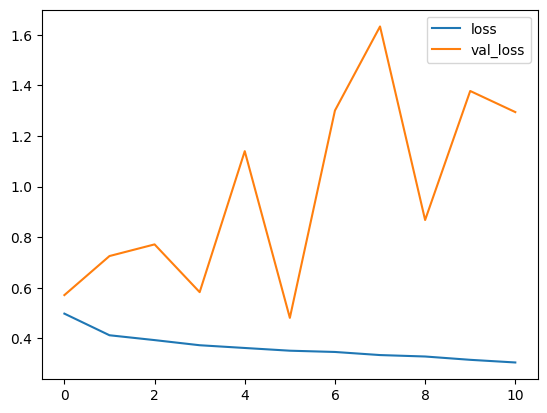

In [117]:
metrics = history.history
plt.plot(history.epoch, metrics['loss'], metrics['val_loss'])
plt.legend(['loss', 'val_loss'])
plt.savefig('loss_plot_9412.png')
plt.show()

In [119]:
commands =  ['scratch', 'rest', 'other']

# 1. Get predictions on the entire validation set
y_true = np.concatenate([y for _, y in val_ds], axis=0)
y_pred_probs = model.predict(val_ds)                # shape: (N, num_classes)
y_pred = np.argmax(y_pred_probs, axis=1)            # predicted class indices

test_acc = sum(y_pred == y_true) / len(y_true)
print(f'Test set accuracy: {test_acc:.0%}')

56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
Test set accuracy: 64%
